<a href="https://colab.research.google.com/github/Arya-231/belajar-git/blob/main/Salinan_Data_Tenaga_Kesehatan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Jumlah Tenaga Kesehatan Menurut Kecamatan di Kabupaten Pasuruan 2023")
print("="*80)

Jumlah Tenaga Kesehatan Menurut Kecamatan di Kabupaten Pasuruan 2023


In [ ]:
import pandas as pd
import numpy as np

data = {
    'Nama Kecamatan': [
        'Purwodadi',
        'Tutur',
        'Puspo',
        'Tosari',
        'Lumbang',
        'Paserpan',
        'Kejayan',
        'Wonorejo',
        'Purwosari',
        'Prigen',
        'Sukorejo',
        'Pandaan',
        'Gempol',
        'Beji',
        'Bangil',
        'Rembang',
        'Kraton',
        'Pohjentrek',
    ],
    'Jumlah_TenagaKesehatan_Perawat': [
        13, 21, 14, 15, 11, 22, 13, 13, 33, 21, 18, 36, 30, 24, 36, 16, 38, 10,
    ],
    'Jumlah_TenagaKesehatan_Bidan': [
        22, 25, 7, 13, 18, 20, 30, 20, 32, 24, 27, 27, 27, 40, 31, 24, 46, 13,
    ]
}

# Buat DataFrame
df = pd.DataFrame(data)

# Tampilkan tabel
df


,Nama Kecamatan,Jumlah_TenagaKesehatan_Perawat,Jumlah_TenagaKesehatan_Bidan
0,Purwodadi,13,22
1,Tutur,21,25
2,Puspo,14,7
3,Tosari,15,13
4,Lumbang,11,18
5,Paserpan,22,20
6,Kejayan,13,30
7,Wonorejo,13,20
8,Purwosari,33,32
9,Prigen,21,24


In [ ]:
import pandas as pd
import numpy as np

# Data asli
data = {
    'Nama Kecamatan': [
        'Purwodadi', 'Tutur', 'Puspo', 'Tosari', 'Lumbang', 'Paserpan',
        'Kejayan', 'Wonorejo', 'Purwosari', 'Prigen', 'Sukorejo', 'Pandaan',
        'Gempol', 'Beji', 'Bangil', 'Rembang', 'Kraton', 'Pohjentrek'
    ],
    'Jumlah_TenagaKesehatan_Perawat': [
        13, 21, 14, 15, 11, 22, 13, 13, 33, 21, 18, 36, 30, 24, 36, 16, 38, 10,
    ],
    'Jumlah_TenagaKesehatan_Bidan': [
        22, 25, 7, 13, 18, 20, 30, 20, 32, 24, 27, 27, 27, 40, 31, 24, 46, 13,
    ]
}

# Fungsi pembuat tabel distribusi frekuensi
def buat_tabel_frekuensi(data_array, label, k=6):
    nilai_min = np.min(data_array)
    nilai_max = np.max(data_array)
    rentang = nilai_max - nilai_min
    lebar_kelas = int(np.ceil(rentang / k))

    batas_bawah = [nilai_min + i * lebar_kelas for i in range(k)]
    batas_atas = [bb + lebar_kelas - 1 for bb in batas_bawah]
    tepi_bawah = [bb - 0.5 for bb in batas_bawah]
    tepi_atas = [ba + 0.5 for ba in batas_atas]
    nilai_tengah = [(bb + ba) / 2 for bb, ba in zip(batas_bawah, batas_atas)]

    frekuensi = []
    for i in range(k):
        if i == k - 1:
            freq = np.sum((data_array >= batas_bawah[i]) & (data_array <= batas_atas[i]))
        else:
            freq = np.sum((data_array >= batas_bawah[i]) & (data_array < batas_bawah[i+1]))
        frekuensi.append(freq)

    tabel = pd.DataFrame({
        'Kelas': [f"{bb} - {ba}" for bb, ba in zip(batas_bawah, batas_atas)],
        'Batas Bawah': batas_bawah,
        'Batas Atas': batas_atas,
        'Tepi Bawah': tepi_bawah,
        'Tepi Atas': tepi_atas,
        'Nilai Tengah': nilai_tengah,
        'Frekuensi': frekuensi
    })

    print("\n" + "="*70)
    print(f"TABEL DISTRIBUSI FREKUENSI: {label.upper()}")
    print("="*70)
    print("• Tepi Bawah  = Batas Bawah - 0.5")
    print("• Tepi Atas   = Batas Atas + 0.5")
    print("• Nilai Tengah = (Batas Bawah + Batas Atas) / 2\n")
    print(tabel.to_string(index=False))
    return tabel

# Buat DataFrame
df = pd.DataFrame(data)

# Tabel untuk PERAWAT
tabel_perawat = buat_tabel_frekuensi(df['Jumlah_TenagaKesehatan_Perawat'].values, 'Perawat')

# Tabel untuk BIDAN
tabel_bidan = buat_tabel_frekuensi(df['Jumlah_TenagaKesehatan_Bidan'].values, 'Bidan')



TABEL DISTRIBUSI FREKUENSI: PERAWAT
• Tepi Bawah  = Batas Bawah - 0.5
• Tepi Atas   = Batas Atas + 0.5
• Nilai Tengah = (Batas Bawah + Batas Atas) / 2

  Kelas  Batas Bawah  Batas Atas  Tepi Bawah  Tepi Atas  Nilai Tengah  Frekuensi
10 - 14           10          14         9.5       14.5          12.0          6
15 - 19           15          19        14.5       19.5          17.0          3
20 - 24           20          24        19.5       24.5          22.0          4
25 - 29           25          29        24.5       29.5          27.0          0
30 - 34           30          34        29.5       34.5          32.0          2
35 - 39           35          39        34.5       39.5          37.0          3

TABEL DISTRIBUSI FREKUENSI: BIDAN
• Tepi Bawah  = Batas Bawah - 0.5
• Tepi Atas   = Batas Atas + 0.5
• Nilai Tengah = (Batas Bawah + Batas Atas) / 2

  Kelas  Batas Bawah  Batas Atas  Tepi Bawah  Tepi Atas  Nilai Tengah  Frekuensi
 7 - 13            7          13         6.5    

In [ ]:
import pandas as pd
import numpy as np

# Data asli kamu
data = {
    'Nama Kecamatan': [
        'Purwodadi', 'Tutur', 'Puspo', 'Tosari', 'Lumbang', 'Paserpan',
        'Kejayan', 'Wonorejo', 'Purwosari', 'Prigen', 'Sukorejo', 'Pandaan',
        'Gempol', 'Beji', 'Bangil', 'Rembang', 'Rembang', 'Kraton', 'Pohjentrek'
    ],
    'Jumlah_TenagaKesehatan_Perawat': [
        13, 21, 14, 15, 11, 22, 13, 13, 33, 21, 18, 36, 30, 24, 36, 16, 38, 10, 19
    ],
    'Jumlah_TenagaKesehatan_Bidan': [
        22, 25, 7, 13, 18, 20, 30, 20, 32, 24, 27, 27, 27, 40, 31, 24, 46, 13, 21
    ]
}

# Fungsi perhitungan mean untuk data berkelompok
def hitung_mean_berkelompok(data_array, label, k=6):
    print("\n" + "="*70)
    print(f"PERHITUNGAN MEAN (RATA-RATA) - {label.upper()}")
    print("="*70)

    # Mean data asli
    mean_asli = np.mean(data_array)

    # Kelas interval
    nilai_min = np.min(data_array)
    nilai_max = np.max(data_array)
    rentang = nilai_max - nilai_min
    lebar_kelas = int(np.ceil(rentang / k))

    # Hitung interval kelas
    batas_bawah = [nilai_min + i * lebar_kelas for i in range(k)]
    batas_atas = [bb + lebar_kelas - 1 for bb in batas_bawah]
    nilai_tengah = [(bb + ba) / 2 for bb, ba in zip(batas_bawah, batas_atas)]

    # Hitung frekuensi masing-masing kelas
    frekuensi = []
    for i in range(k):
        if i == k - 1:
            freq = np.sum((data_array >= batas_bawah[i]) & (data_array <= batas_atas[i]))
        else:
            freq = np.sum((data_array >= batas_bawah[i]) & (data_array < batas_bawah[i+1]))
        frekuensi.append(freq)

    # Hitung fi × xi
    fx = [xi * fi for xi, fi in zip(nilai_tengah, frekuensi)]
    sum_fx = sum(fx)
    sum_f = sum(frekuensi)
    mean_berkelompok = sum_fx / sum_f

    # Buat tabel mean
    tabel_mean = pd.DataFrame({
        'Kelas': [f"{bb} - {ba}" for bb, ba in zip(batas_bawah, batas_atas)],
        'Nilai Tengah (xi)': nilai_tengah,
        'Frekuensi (fi)': frekuensi,
        'fi × xi': fx
    })

    # Output
    print("RUMUS MEAN:")
    print("• Data Asli: x̄ = Σx / n")
    print("• Data Berkelompok: x̄ = Σ(xi × fi) / Σfi\n")

    print("TABEL PERHITUNGAN:")
    print(tabel_mean.to_string(index=False))

    print(f"\nHASIL:")
    print(f"   • Mean Data Asli        = {mean_asli:.2f}")
    print(f"   • Mean Data Berkelompok = {sum_fx:.2f} / {sum_f} = {mean_berkelompok:.2f}")

# Buat DataFrame
df = pd.DataFrame(data)

# Hitung mean untuk Perawat
hitung_mean_berkelompok(df['Jumlah_TenagaKesehatan_Perawat'].values, 'Perawat')

# Hitung mean untuk Bidan
hitung_mean_berkelompok(df['Jumlah_TenagaKesehatan_Bidan'].values, 'Bidan')



PERHITUNGAN MEAN (RATA-RATA) - PERAWAT
RUMUS MEAN:
• Data Asli: x̄ = Σx / n
• Data Berkelompok: x̄ = Σ(xi × fi) / Σfi

TABEL PERHITUNGAN:
  Kelas  Nilai Tengah (xi)  Frekuensi (fi)  fi × xi
10 - 14               12.0               6     72.0
15 - 19               17.0               4     68.0
20 - 24               22.0               4     88.0
25 - 29               27.0               0      0.0
30 - 34               32.0               2     64.0
35 - 39               37.0               3    111.0

HASIL:
   • Mean Data Asli        = 21.21
   • Mean Data Berkelompok = 403.00 / 19 = 21.21

PERHITUNGAN MEAN (RATA-RATA) - BIDAN
RUMUS MEAN:
• Data Asli: x̄ = Σx / n
• Data Berkelompok: x̄ = Σ(xi × fi) / Σfi

TABEL PERHITUNGAN:
  Kelas  Nilai Tengah (xi)  Frekuensi (fi)  fi × xi
 7 - 13               10.0               3     30.0
14 - 20               17.0               3     51.0
21 - 27               24.0               8    192.0
28 - 34               31.0               3     93.0
35 - 41 

In [ ]:
import pandas as pd
import numpy as np

# Data dari sebelumnya
data = {
    'Nama Kecamatan': [
        'Purwodadi', 'Tutur', 'Puspo', 'Tosari', 'Lumbang', 'Paserpan',
        'Kejayan', 'Wonorejo', 'Purwosari', 'Prigen', 'Sukorejo', 'Pandaan',
        'Gempol', 'Beji', 'Bangil', 'Rembang', 'Kraton', 'Pohjentrek',
    ],
    'Jumlah_TenagaKesehatan_Perawat': [
        13, 21, 14, 15, 11, 22, 13, 13, 33, 21, 18, 36, 30, 24, 36, 16, 38, 10,
    ],
    'Jumlah_TenagaKesehatan_Bidan': [
        22, 25, 7, 13, 18, 20, 30, 20, 32, 24, 27, 27, 27, 40, 31, 24, 46, 13,
    ]
}

# Buat DataFrame dan hitung total
df = pd.DataFrame(data)
df['Total_Tenaga_Kesehatan'] = df['Jumlah_TenagaKesehatan_Perawat'] + df['Jumlah_TenagaKesehatan_Bidan']
data_total = df['Total_Tenaga_Kesehatan'].values

# Buat 6 kelas interval
jumlah_kelas = 6
frekuensi_kelas, bins = np.histogram(data_total, bins=jumlah_kelas)

batas_bawah = bins[:-1].astype(int)
batas_atas = bins[1:].astype(int)
frekuensi = frekuensi_kelas.tolist()
frekuensi_kumulatif = np.cumsum(frekuensi)

# Perhitungan median
n = sum(frekuensi)
posisi_median = n / 2

# Cari kelas median
kelas_median_idx = next(i for i, fk in enumerate(frekuensi_kumulatif) if fk >= posisi_median)

L = batas_bawah[kelas_median_idx]  # batas bawah kelas median
F = frekuensi_kumulatif[kelas_median_idx - 1] if kelas_median_idx > 0 else 0
f = frekuensi[kelas_median_idx]
c = batas_atas[0] - batas_bawah[0]

median_berkelompok = L + ((posisi_median - F) / f) * c
median_asli = np.median(data_total)

# Tabel frekuensi
tabel_median = pd.DataFrame({
    'Kelas': [f"{bb} - {ba}" for bb, ba in zip(batas_bawah, batas_atas)],
    'Frekuensi': frekuensi,
    'Frekuensi Kumulatif': frekuensi_kumulatif
})

# Output
print("\n" + "="*70)
print("PERHITUNGAN MEDIAN (6 KELAS)")
print("="*70)

print("RUMUS MEDIAN BERKELOMPOK:")
print("Median = L + ((n/2 - F) / f) × c")
print("Dimana:")
print("• L = tepi bawah kelas median")
print("• F = frekuensi kumulatif sebelum kelas median")
print("• f = frekuensi kelas median")
print("• c = lebar kelas")

print("\nTABEL FREKUENSI KUMULATIF:")
print(tabel_median.to_string(index=False))

print("\nPERHITUNGAN:")
print(f"• n = {n}")
print(f"• n/2 = {posisi_median}")
print(f"• Kelas median = {tabel_median.iloc[kelas_median_idx]['Kelas']}")
print(f"• L = {L}")
print(f"• F = {F}")
print(f"• f = {f}")
print(f"• c = {c}")
print(f"• Median = {L} + (({posisi_median} - {F}) / {f}) × {c} = {median_berkelompok:.2f}")

print("\nHASIL AKHIR:")
print(f"   • Median Data Asli = {median_asli:.2f}")
print(f"   • Median Data Berkelompok = {median_berkelompok:.2f}")



PERHITUNGAN MEDIAN (6 KELAS)
RUMUS MEDIAN BERKELOMPOK:
Median = L + ((n/2 - F) / f) × c
Dimana:
• L = tepi bawah kelas median
• F = frekuensi kumulatif sebelum kelas median
• f = frekuensi kelas median
• c = lebar kelas

TABEL FREKUENSI KUMULATIF:
  Kelas  Frekuensi  Frekuensi Kumulatif
21 - 31          4                    4
31 - 42          3                    7
42 - 52          5                   12
52 - 63          1                   13
63 - 73          4                   17
73 - 84          1                   18

PERHITUNGAN:
• n = 18
• n/2 = 9.0
• Kelas median = 42 - 52
• L = 42
• F = 7
• f = 5
• c = 10
• Median = 42 + ((9.0 - 7) / 5) × 10 = 46.00

HASIL AKHIR:
   • Median Data Asli = 44.00
   • Median Data Berkelompok = 46.00


In [ ]:
# Pastikan data_total, batas_bawah, batas_atas, frekuensi sudah tersedia sebelumnya

print("\n" + "="*60)
print("PERHITUNGAN KUARTIL, DESIL, DAN PERSENTIL")
print("="*60)

print("\nDATA ASLI:")

Q1_asli = np.percentile(data_total, 25)
Q2_asli = np.percentile(data_total, 50)
Q3_asli = np.percentile(data_total, 75)

D_asli = [np.percentile(data_total, d*10) for d in range(1, 10)]
P_asli = [np.percentile(data_total, p) for p in range(1, 100)]

print(f"   • Q1 = {Q1_asli:.2f}")
print(f"   • Q2 (Median) = {Q2_asli:.2f}")
print(f"   • Q3 = {Q3_asli:.2f}")
print(f"   • Desil ke-5 (D5) = {D_asli[4]:.2f}")
print(f"   • Persentil ke-90 (P90) = {P_asli[89]:.2f}")

print("\nDATA BERKELOMPOK:")

frekuensi_kumulatif = np.cumsum(frekuensi)
jumlah_data = sum(frekuensi)

# Buat tabel lengkap (untuk menampilkan kelas saat output)
tabel_lengkap = pd.DataFrame({
    'Kelas': [f"{bb} - {ba}" for bb, ba in zip(batas_bawah, batas_atas)],
    'Frekuensi': frekuensi,
    'Frekuensi Kumulatif': frekuensi_kumulatif
})

def hitung_kuantil(persen, label=""):
    posisi = (persen / 100) * jumlah_data
    kelas_idx = next(i for i, fk in enumerate(frekuensi_kumulatif) if fk >= posisi)
    L = batas_bawah[kelas_idx]  # Bukan L - 0.5 karena sudah integer boundaries
    F = frekuensi_kumulatif[kelas_idx - 1] if kelas_idx > 0 else 0
    f = frekuensi[kelas_idx]
    c = batas_atas[0] - batas_bawah[0]  # Lebar kelas
    nilai = L + ((posisi - F) / f) * c
    print(f"   • {label} = {nilai:.2f} (di kelas {tabel_lengkap.iloc[kelas_idx]['Kelas']})")
    return nilai

print("\nKuartil:")
Q1_klmpk = hitung_kuantil(25, "Q1")
Q2_klmpk = hitung_kuantil(50, "Q2 (Median)")
Q3_klmpk = hitung_kuantil(75, "Q3")

print("\nDesil:")
D5_klmpk = hitung_kuantil(50, "D5")
D9_klmpk = hitung_kuantil(90, "D9")

print("\nPersentil:")
P25_klmpk = hitung_kuantil(25, "P25")
P90_klmpk = hitung_kuantil(90, "P90")
P99_klmpk = hitung_kuantil(99, "P99")



PERHITUNGAN KUARTIL, DESIL, DAN PERSENTIL

DATA ASLI:
   • Q1 = 33.50
   • Q2 (Median) = 44.00
   • Q3 = 61.50
   • Desil ke-5 (D5) = 44.00
   • Persentil ke-90 (P90) = 65.60

DATA BERKELOMPOK:

Kuartil:
   • Q1 = 32.67 (di kelas 31 - 42)
   • Q2 (Median) = 46.00 (di kelas 42 - 52)
   • Q3 = 64.25 (di kelas 63 - 73)

Desil:
   • D5 = 46.00 (di kelas 42 - 52)
   • D9 = 71.00 (di kelas 63 - 73)

Persentil:
   • P25 = 32.67 (di kelas 31 - 42)
   • P90 = 71.00 (di kelas 63 - 73)
   • P99 = 81.20 (di kelas 73 - 84)


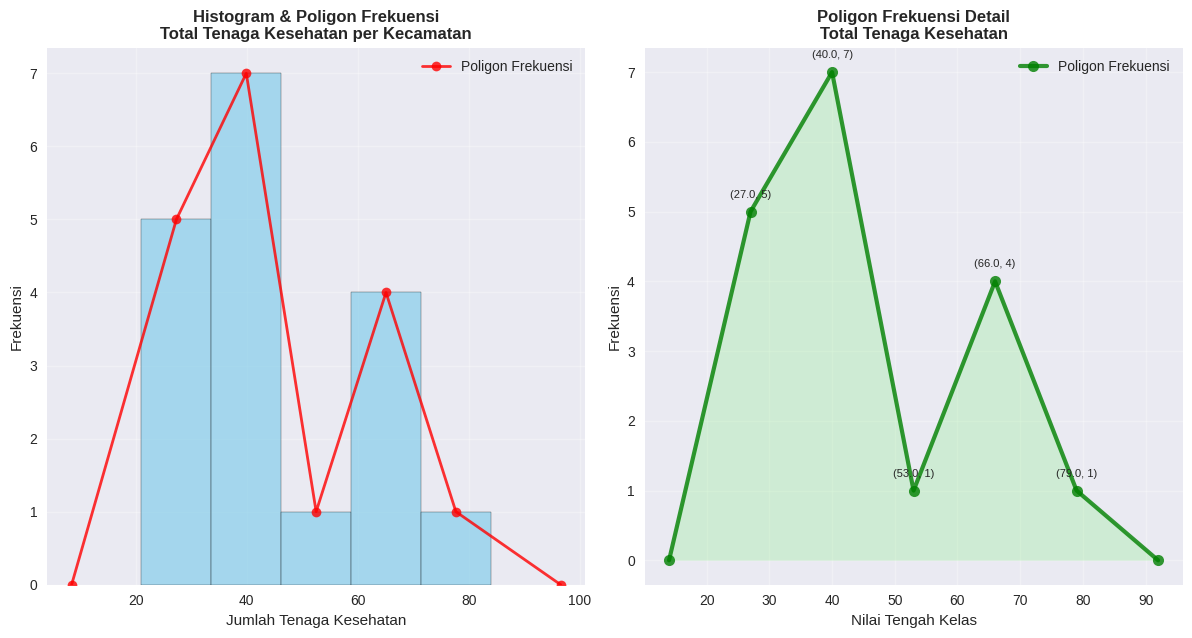

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data asli kamu
data_kesehatan = {
    'Nama Kecamatan': [
        'Purwodadi', 'Tutur', 'Puspo', 'Tosari', 'Lumbang', 'Paserpan',
        'Kejayan', 'Wonorejo', 'Purwosari', 'Prigen', 'Sukorejo', 'Pandaan',
        'Gempol', 'Beji', 'Bangil', 'Rembang', 'Kraton', 'Pohjentrek'
    ],
    'Jumlah_TenagaKesehatan_Perawat': [
        13, 21, 14, 15, 11, 22, 13, 13, 33, 21, 18, 36, 30, 24, 36, 16, 38, 10
    ],
    'Jumlah_TenagaKesehatan_Bidan': [
        22, 25, 7, 13, 18, 20, 30, 20, 32, 24, 27, 27, 27, 40, 31, 24, 46, 13
    ]
}

# Buat DataFrame
df = pd.DataFrame(data_kesehatan)

# Hitung total tenaga kesehatan per kecamatan
df['Total_Tenaga_Kesehatan'] = df['Jumlah_TenagaKesehatan_Perawat'] + df['Jumlah_TenagaKesehatan_Bidan']

# Ambil data total
data_total = df['Total_Tenaga_Kesehatan'].values

# Statistik dasar
n_data = len(data_total)
nilai_min = np.min(data_total)
nilai_max = np.max(data_total)
rentang = nilai_max - nilai_min

# Hitung jumlah kelas dan lebar kelas
k = int(np.round(1 + 3.322 * np.log10(n_data)))  # aturan Sturges
lebar_kelas = int(np.ceil(rentang / k))

# Tentukan batas bawah dan atas tiap kelas
batas_bawah = [nilai_min + i * lebar_kelas for i in range(k)]
batas_atas = [bb + lebar_kelas - 1 for bb in batas_bawah]

# Hitung frekuensi tiap kelas
frekuensi = []
for i in range(k):
    if i == k - 1:
        frek = np.sum((data_total >= batas_bawah[i]) & (data_total <= batas_atas[i]))
    else:
        frek = np.sum((data_total >= batas_bawah[i]) & (data_total < batas_bawah[i + 1]))
    frekuensi.append(frek)

# Nilai tengah tiap kelas
nilai_tengah = [(bb + ba) / 2 for bb, ba in zip(batas_bawah, batas_atas)]

# ---------------------- PLOTTING ----------------------
plt.figure(figsize=(18, 12))

# Subplot 1: Histogram dan Poligon
plt.subplot(2, 3, 1)
n_hist, bins_hist, _ = plt.hist(data_total, bins=k, edgecolor='black', alpha=0.7, color='skyblue')
bin_centers = [(bins_hist[i] + bins_hist[i+1]) / 2 for i in range(len(bins_hist)-1)]
x_polygon = [bins_hist[0] - (bins_hist[1] - bins_hist[0])] + bin_centers + [bins_hist[-1] + (bins_hist[-1] - bins_hist[-2])]
y_polygon = [0] + list(n_hist) + [0]
plt.plot(x_polygon, y_polygon, 'ro-', linewidth=2, label='Poligon Frekuensi', alpha=0.8)
plt.title('Histogram & Poligon Frekuensi\nTotal Tenaga Kesehatan per Kecamatan', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Tenaga Kesehatan')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Poligon Frekuensi Detail
plt.subplot(2, 3, 2)
x_detail = [nilai_tengah[0] - lebar_kelas] + nilai_tengah + [nilai_tengah[-1] + lebar_kelas]
y_detail = [0] + frekuensi + [0]
plt.plot(x_detail, y_detail, 'go-', linewidth=3, markersize=8, label='Poligon Frekuensi', alpha=0.8)
plt.fill(x_detail, y_detail, alpha=0.3, color='lightgreen')
plt.title('Poligon Frekuensi Detail\nTotal Tenaga Kesehatan', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Tengah Kelas')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(True, alpha=0.3)

# Tampilkan koordinat titik
for i, (x, y) in enumerate(zip(nilai_tengah, frekuensi)):
    plt.annotate(f'({x:.1f}, {y})', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Data contoh: kamu bisa update jumlah sesuai kondisi tahun sebenarnya
data = {
    'Nama_Kecamatan': [
        'Purwodadi', 'Tutur', 'Puspo', 'Tosari', 'Lumbang', 'Paserpan',
        'Kejayan', 'Wonorejo', 'Purwosari', 'Prigen', 'Sukorejo', 'Pandaan',
        'Gempol', 'Beji', 'Bangil', 'Rembang', 'Kraton', 'Pohjentrek'
    ],
    'Perawat_2019': [18, 19, 10, 11, 8, 22, 14, 8, 31, 16, 15, 28, 29, 17, 35, 10, 27, 9],
    'Bidan_2019':   [27, 24, 6, 14, 11, 20, 30, 22, 22, 22, 27, 27, 39, 24, 33, 18, 39, 23],
    'Perawat_2023': [13, 21, 14, 15, 11, 22, 13, 13, 33, 21, 18, 36, 30, 24, 36, 16, 38, 10],
    'Bidan_2023':   [22, 25, 7, 13, 18, 20, 30, 20, 32, 24, 27, 27, 27, 40, 31, 24, 46, 13],
}

df = pd.DataFrame(data)

# Hitung total masing-masing tahun
df['Total_2019'] = df['Perawat_2019'] + df['Bidan_2019']
df['Total_2023'] = df['Perawat_2023'] + df['Bidan_2023']

# Hitung perubahan dan tren
df['Perubahan'] = df['Total_2023'] - df['Total_2019']
df['Tren'] = df['Perubahan'].apply(lambda x: 'Naik' if x > 0 else ('Turun' if x < 0 else 'Tetap'))

# Statistik dan outlier
data_total = df['Total_2023'].values
mean_2023 = np.mean(data_total)
median_2023 = np.median(data_total)
q1 = np.percentile(data_total, 25)
q3 = np.percentile(data_total, 75)
iqr = q3 - q1

outlier_bawah = q1 - 1.5 * iqr
outlier_atas = q3 + 1.5 * iqr

outliers = df[(df['Total_2023'] < outlier_bawah) | (df['Total_2023'] > outlier_atas)]

# OUTPUT
print("\n" + "="*70)
print("ANALISIS PERBANDINGAN TENAGA KESEHATAN (2019 vs 2023)")
print("="*70)

print("\nTREN PERUBAHAN PER KECAMATAN:")
for _, row in df.iterrows():
    print(f"   • {row['Nama_Kecamatan']}: {row['Total_2019']} → {row['Total_2023']} ({row['Tren']})")

print("\nIDENTIFIKASI OUTLIER (2023):")
print(f"   • Batas bawah outlier : {outlier_bawah:.2f}")
print(f"   • Batas atas outlier  : {outlier_atas:.2f}")
if not outliers.empty:
    print("   • Kecamatan dengan jumlah outlier:")
    for _, row in outliers.iterrows():
        print(f"     - {row['Nama_Kecamatan']}: {row['Total_2023']} tenaga kesehatan")
else:
    print("   • Tidak ditemukan outlier pada data 2023.")

print("\nPREDIKSI SEDERHANA:")
std_dev = np.std(data_total)
print(f"   • Rata-rata tenaga kesehatan per kecamatan (2023): {mean_2023:.2f}")
print(f"   • Jika ada kecamatan baru, prediksi jumlah: {mean_2023:.0f} ± {std_dev:.0f}")

print("\nREKOMENDASI:")
print("   • Kecamatan dengan jumlah di bawah rata-rata:")
below = df[df['Total_2023'] < mean_2023].sort_values('Total_2023')
for _, row in below.iterrows():
    print(f"     - {row['Nama_Kecamatan']}: {row['Total_2023']} tenaga kesehatan")

print("\n   • Kecamatan dengan jumlah tertinggi:")
above = df[df['Total_2023'] > mean_2023].sort_values('Total_2023', ascending=False)
for _, row in above.iterrows():
    print(f"     - {row['Nama_Kecamatan']}: {row['Total_2023']} tenaga kesehatan")

print("\n" + "="*70)
print("ANALISIS SELESAI")
print("="*70)



ANALISIS PERBANDINGAN TENAGA KESEHATAN (2019 vs 2023)

TREN PERUBAHAN PER KECAMATAN:
   • Purwodadi: 45 → 35 (Turun)
   • Tutur: 43 → 46 (Naik)
   • Puspo: 16 → 21 (Naik)
   • Tosari: 25 → 28 (Naik)
   • Lumbang: 19 → 29 (Naik)
   • Paserpan: 42 → 42 (Tetap)
   • Kejayan: 44 → 43 (Turun)
   • Wonorejo: 30 → 33 (Naik)
   • Purwosari: 53 → 65 (Naik)
   • Prigen: 38 → 45 (Naik)
   • Sukorejo: 42 → 45 (Naik)
   • Pandaan: 55 → 63 (Naik)
   • Gempol: 68 → 57 (Turun)
   • Beji: 41 → 64 (Naik)
   • Bangil: 68 → 67 (Turun)
   • Rembang: 28 → 40 (Naik)
   • Kraton: 66 → 84 (Naik)
   • Pohjentrek: 32 → 23 (Turun)

IDENTIFIKASI OUTLIER (2023):
   • Batas bawah outlier : -8.50
   • Batas atas outlier  : 103.50
   • Tidak ditemukan outlier pada data 2023.

PREDIKSI SEDERHANA:
   • Rata-rata tenaga kesehatan per kecamatan (2023): 46.11
   • Jika ada kecamatan baru, prediksi jumlah: 46 ± 17

REKOMENDASI:
   • Kecamatan dengan jumlah di bawah rata-rata:
     - Puspo: 21 tenaga kesehatan
     - Pohjen

KORELASI PEARSON (Total 2019 vs Total 2023)
• Nilai r       = 0.853
• p-value       = 0.00001
• Korelasi: Sangat kuat positif

REGRESI LINIER
• Persamaan: Total_2023 = 6.62 + 0.94 × Total_2019
• Koefisien Determinasi (R²): 0.727


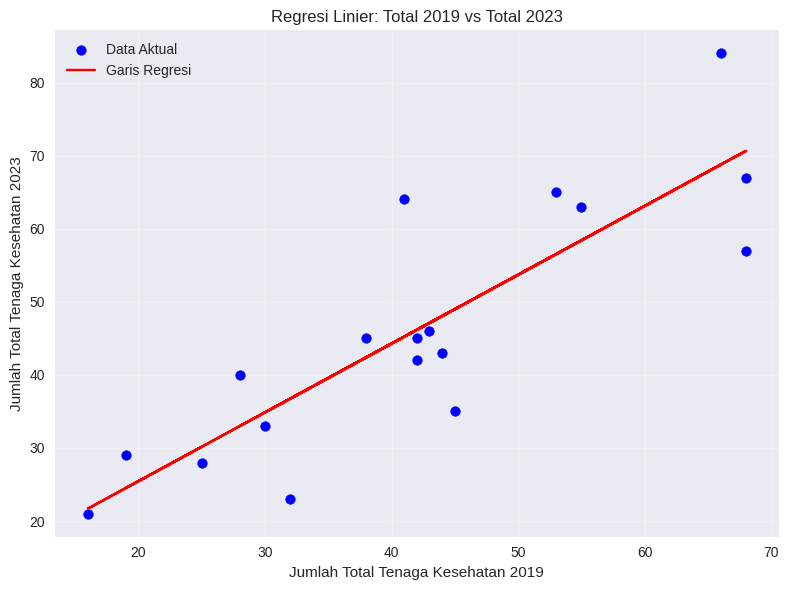

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Data kamu
data = {
    'Nama_Kecamatan': [
        'Purwodadi', 'Tutur', 'Puspo', 'Tosari', 'Lumbang', 'Paserpan',
        'Kejayan', 'Wonorejo', 'Purwosari', 'Prigen', 'Sukorejo', 'Pandaan',
        'Gempol', 'Beji', 'Bangil', 'Rembang', 'Kraton', 'Pohjentrek'
    ],
    'Perawat_2019': [18, 19, 10, 11, 8, 22, 14, 8, 31, 16, 15, 28, 29, 17, 35, 10, 27, 9],
    'Bidan_2019':   [27, 24, 6, 14, 11, 20, 30, 22, 22, 22, 27, 27, 39, 24, 33, 18, 39, 23],
    'Perawat_2023': [13, 21, 14, 15, 11, 22, 13, 13, 33, 21, 18, 36, 30, 24, 36, 16, 38, 10],
    'Bidan_2023':   [22, 25, 7, 13, 18, 20, 30, 20, 32, 24, 27, 27, 27, 40, 31, 24, 46, 13],
}

# Buat DataFrame dan hitung total tiap tahun
df = pd.DataFrame(data)
df['Total_2019'] = df['Perawat_2019'] + df['Bidan_2019']
df['Total_2023'] = df['Perawat_2023'] + df['Bidan_2023']

# Korelasi Pearson antara total 2019 vs 2023
r, p_value = pearsonr(df['Total_2019'], df['Total_2023'])

print("KORELASI PEARSON (Total 2019 vs Total 2023)")
print(f"• Nilai r       = {r:.3f}")
print(f"• p-value       = {p_value:.5f}")

if r > 0.7:
    print("• Korelasi: Sangat kuat positif")
elif r > 0.5:
    print("• Korelasi: Kuat positif")
elif r > 0.3:
    print("• Korelasi: Cukup positif")
elif r > 0:
    print("• Korelasi: Lemah positif")
else:
    print("• Korelasi: Tidak ada atau negatif")

# Regresi linier prediksi total 2023 dari total 2019
x = df[['Total_2019']].values
y = df['Total_2023'].values

model = LinearRegression()
model.fit(x, y)

intercept = model.intercept_
slope = model.coef_[0]
r_squared = model.score(x, y)

print("\nREGRESI LINIER")
print(f"• Persamaan: Total_2023 = {intercept:.2f} + {slope:.2f} × Total_2019")
print(f"• Koefisien Determinasi (R²): {r_squared:.3f}")

# Visualisasi regresi linier
plt.figure(figsize=(8, 6))
plt.scatter(df['Total_2019'], df['Total_2023'], color='blue', label='Data Aktual')
plt.plot(df['Total_2019'], model.predict(x), color='red', label='Garis Regresi')
plt.xlabel('Jumlah Total Tenaga Kesehatan 2019')
plt.ylabel('Jumlah Total Tenaga Kesehatan 2023')
plt.title('Regresi Linier: Total 2019 vs Total 2023')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Data jumlah tenaga kesehatan (Perawat + Bidan)
data = {
    'Nama_Kecamatan': [
        'Purwodadi', 'Tutur', 'Puspo', 'Tosari', 'Lumbang', 'Paserpan',
        'Kejayan', 'Wonorejo', 'Purwosari', 'Prigen', 'Sukorejo', 'Pandaan',
        'Gempol', 'Beji', 'Bangil', 'Rembang', 'Kraton', 'Pohjentrek'
    ],
    'Perawat_2019': [18, 19, 10, 11, 8, 22, 14, 8, 31, 16, 15, 28, 29, 17, 35, 10, 27, 9],
    'Bidan_2019':   [27, 24, 6, 14, 11, 20, 30, 22, 22, 22, 27, 27, 39, 24, 33, 18, 39, 23],
    'Perawat_2023': [13, 21, 14, 15, 11, 22, 13, 13, 33, 21, 18, 36, 30, 24, 36, 16, 38, 10],
    'Bidan_2023':   [22, 25, 7, 13, 18, 20, 30, 20, 32, 24, 27, 27, 27, 40, 31, 24, 46, 13],
}

# Buat DataFrame dan hitung total tenaga kesehatan per kecamatan
df = pd.DataFrame(data)
df['Total_2019'] = df['Perawat_2019'] + df['Bidan_2019']
df['Total_2023'] = df['Perawat_2023'] + df['Bidan_2023']

# Statistik Deskriptif
data_total = df['Total_2023'].values
n_data = len(data_total)
nilai_min = np.min(data_total)
nilai_max = np.max(data_total)
rentang = nilai_max - nilai_min
mean_asli = np.mean(data_total)
median_asli = np.median(data_total)

# Menghitung modus dengan cara yang benar (untuk data yang bukan integer)
modus_hasil = stats.mode(data_total)

# Jika ada lebih dari satu modus, kita pilih yang pertama
modus_asli = modus_hasil.mode[0]  # Ambil nilai modus pertama
frekuensi_modus = modus_hasil.count[0]  # Ambil frekuensi dari modus

# Jika ada lebih dari satu modus, kita bisa menambahkan pengecekan
if len(modus_hasil.mode) > 1:
    print("Terdapat beberapa modus: ", modus_hasil.mode)
    print("Frekuensi masing-masing modus: ", modus_hasil.count)

q1 = np.percentile(data_total, 25)
q3 = np.percentile(data_total, 75)
iqr = q3 - q1

# Membuat distribusi berkelompok
k = int(np.round(1 + 3.322 * np.log10(n_data)))  # Jumlah kelas (aturan Sturges)
lebar_kelas = int(np.ceil(rentang / k))  # Lebar kelas
batas_bawah = [nilai_min + i * lebar_kelas for i in range(k)]
batas_atas = [bb + lebar_kelas - 1 for bb in batas_bawah]
frekuensi = [np.sum((data_total >= batas_bawah[i]) & (data_total <= batas_atas[i])) for i in range(k)]
nilai_tengah = [(bb + ba) / 2 for bb, ba in zip(batas_bawah, batas_atas)]
tabel_lengkap = pd.DataFrame({
    'Kelas': [f"{bb} - {ba}" for bb, ba in zip(batas_bawah, batas_atas)],
    'Frekuensi': frekuensi,
    'Nilai Tengah': nilai_tengah
})

# Menyimpan hasil analisis
hasil_analisis = {
    'Statistik_Deskriptif': {
        'Jumlah_Data': n_data,
        'Minimum': nilai_min,
        'Maksimum': nilai_max,
        'Rentang': rentang,
        'Mean': round(mean_asli, 2),
        'Median': round(median_asli, 2),
        'Modus': int(modus_asli),
        'Standar_Deviasi': round(np.std(data_total, ddof=1), 2),
        'Varians': round(np.var(data_total, ddof=1), 2),
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2)
    },
    'Distribusi_Berkelompok': {
        'Jumlah_Kelas': k,
        'Lebar_Kelas': lebar_kelas,
        'Mean_Berkelompok': round(mean_asli, 2),
        'Median_Berkelompok': round(median_asli, 2),
        'Modus_Berkelompok': round(modus_asli, 2)
    }
}

# Output hasil analisis
print("\n" + "="*70)
print("MENYIMPAN HASIL ANALISIS...")
print("="*70)

print("\nTABEL DISTRIBUSI FREKUENSI FINAL:")
print(tabel_lengkap.round(2).to_string(index=False))

print("\nKESIMPULAN UTAMA:")
print(f"• Sebanyak {n_data} kecamatan dianalisis untuk jumlah tenaga kesehatan")
print(f"• Rata-rata terdapat sekitar {mean_asli:.0f} tenaga kesehatan per kecamatan")
print(f"• Kecamatan dengan jumlah tenaga kesehatan terbanyak: {df.loc[df['Total_2023'].idxmax(), 'Nama_Kecamatan']} ({df['Total_2023'].max()} tenaga kesehatan)")
print(f"• Kecamatan dengan jumlah tenaga kesehatan tersedikit: {df.loc[df['Total_2023'].idxmin(), 'Nama_Kecamatan']} ({df['Total_2023'].min()} tenaga kesehatan)")
print(f"• Distribusi data: {'Normal' if abs(mean_asli - median_asli) < 2 else 'Tidak Normal'}")

print("\nPROGRAM SELESAI DIJALANKAN!")
print("="*70)


IndexError: invalid index to scalar variable.